# EmpaticaE4Stress dataset
ref) https://data.mendeley.com/datasets/kb42z77m2g/2

In [5]:
for fp in [
    "/content/drive/MyDrive/Colab Notebooks/datasets/EmpaticaE4Stress/subject_01/BVP.csv",
    "/content/drive/MyDrive/Colab Notebooks/datasets/EmpaticaE4Stress/subject_01/EDA.csv",
    "/content/drive/MyDrive/Colab Notebooks/datasets/EmpaticaE4Stress/subject_01/IBI.csv",
]:
    print("\n", "="*30, fp, "="*30)
    with open(fp, "r", encoding="utf-8", errors="replace") as f:
        for i in range(15):
            line = f.readline()
            if not line:
                break
            print(f"{i+1:02d}: {repr(line.rstrip())}")


 ============================== /content/drive/MyDrive/Colab Notebooks/datasets/EmpaticaE4Stress/subject_01/BVP.csv ==============================
01: '0'
02: '0'
03: '0'
04: '0'
05: '0'
06: '0'
07: '0'
08: '0'
09: '0'
10: '0'
11: '0'
12: '0.01'
13: '0.01'
14: '0'
15: '-0.03'

 ============================== /content/drive/MyDrive/Colab Notebooks/datasets/EmpaticaE4Stress/subject_01/EDA.csv ==============================
01: '0'
02: '0.830302'
03: '1.17781'
04: '1.616094'
05: '2.09413'
06: '2.48001'
07: '2.469697'
08: '2.47226'
09: '2.467135'
10: '2.464572'
11: '2.459447'
12: '2.456884'
13: '2.447915'
14: '2.449196'
15: '2.465853'

 ============================== /content/drive/MyDrive/Colab Notebooks/datasets/EmpaticaE4Stress/subject_01/IBI.csv ==============================
01: '20.96875,0.859375'
02: '21.8125,0.84375'
03: '22.625,0.8125'
04: '23.421875,0.796875'
05: '24.234375,0.8125'
06: '25.078125,0.84375'
07: '54.859375,0.828125'
08: '55.71875,0.859375'
09: '56.5625,0.84375'
10:

DATASET BASIC CHECK
Total subjects: 29

[Existence]
BVP all present: True
EDA all present: True
IBI all present: True

[Sampling Rate]
Unique BVP fs: [64.0]
Unique EDA fs: [4.0]

[NaN Count]
Total BVP NaNs: 0
Total EDA NaNs: 0
Total IBI NaNs: 0

[Duration Range]
BVP duration range (sec): 2053.734375 ~ 2655.46875
EDA duration range (sec): 0.5 ~ 2505.0
IBI duration range (sec): 1355.3125 ~ 2603.9375

[IBI Mean Range]
IBI mean (sec): 0.6639583333333333 ~ 1.1614583333333333

[Summary head]
      subject  BVP_exists  BVP_fs   BVP_n  BVP_duration_sec  BVP_nan_count  \
0  subject_01        True    64.0  160369       2505.765625              0   
1  subject_02        True    64.0  150777       2355.890625              0   
2  subject_03        True    64.0  132880       2076.250000              0   
3  subject_04        True    64.0  134959       2108.734375              0   
4  subject_05        True    64.0  133364       2083.812500              0   

   BVP_min  BVP_max  EDA_exists  EDA_fs 

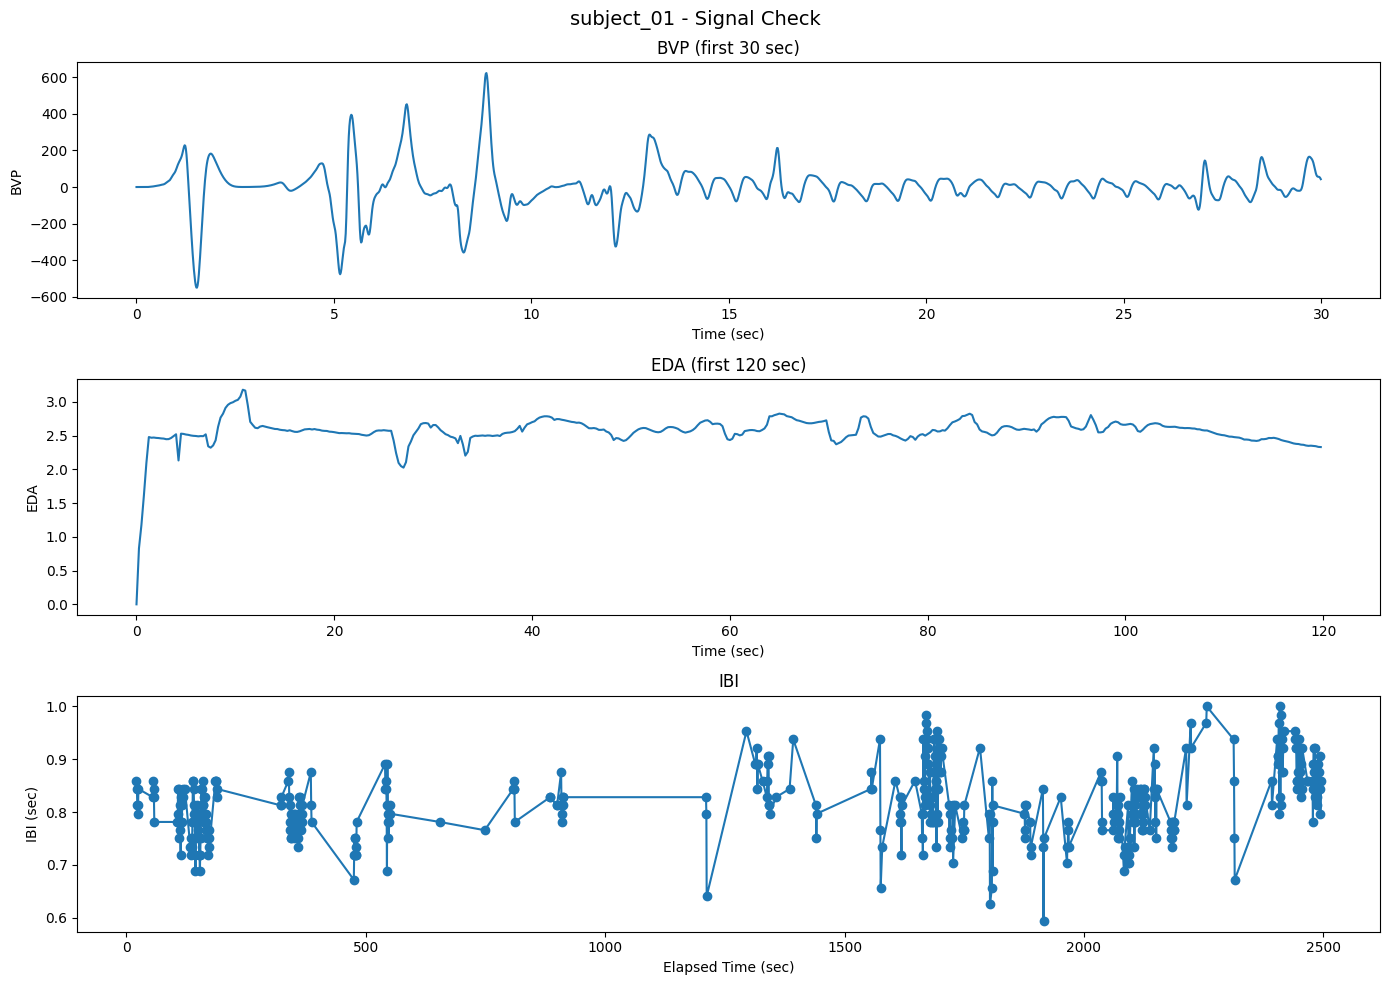

In [6]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
ROOT_DIR = r"/content/drive/MyDrive/Colab Notebooks/datasets/EmpaticaE4Stress"

FS_BVP = 64.0
FS_EDA = 4.0


# =========================================================
# LOADERS
# =========================================================
def load_bvp(file_path, fs=FS_BVP):
    """
    BVP.csv
    - 1 column
    - raw BVP values only
    - no header
    """
    df = pd.read_csv(file_path, header=None)
    data = pd.to_numeric(df.iloc[:, 0], errors="coerce").dropna().to_numpy(dtype=np.float64)

    timestamps = np.arange(len(data)) / fs

    return {
        "data": data,
        "timestamps": timestamps,
        "fs": fs,
        "n_samples": len(data),
        "duration_sec": len(data) / fs,
    }


def load_eda(file_path, fs=FS_EDA):
    """
    EDA.csv
    - 1 column
    - raw EDA values only
    - no header
    """
    df = pd.read_csv(file_path, header=None)
    data = pd.to_numeric(df.iloc[:, 0], errors="coerce").dropna().to_numpy(dtype=np.float64)

    timestamps = np.arange(len(data)) / fs

    return {
        "data": data,
        "timestamps": timestamps,
        "fs": fs,
        "n_samples": len(data),
        "duration_sec": len(data) / fs,
    }


def load_ibi(file_path):
    """
    IBI.csv
    - 2 columns: offset_sec, ibi_sec
    - no header
    """
    df = pd.read_csv(file_path, header=None)

    if df.shape[1] < 2:
        raise ValueError(f"IBI file format error: expected 2 columns, got {df.shape[1]} -> {file_path}")

    offsets = pd.to_numeric(df.iloc[:, 0], errors="coerce").to_numpy(dtype=np.float64)
    ibis = pd.to_numeric(df.iloc[:, 1], errors="coerce").to_numpy(dtype=np.float64)

    valid = ~np.isnan(offsets) & ~np.isnan(ibis)
    offsets = offsets[valid]
    ibis = ibis[valid]

    return {
        "data": ibis,
        "timestamps": offsets,   # 여기선 absolute time이 아니라 elapsed time
        "offsets": offsets,
        "n_samples": len(ibis),
        "duration_sec": float(offsets[-1] - offsets[0]) if len(offsets) > 1 else 0.0,
        "ibi_mean_sec": float(np.mean(ibis)) if len(ibis) > 0 else np.nan,
    }


def load_subject(subject_dir):
    subject_data = {}

    bvp_path = os.path.join(subject_dir, "BVP.csv")
    eda_path = os.path.join(subject_dir, "EDA.csv")
    ibi_path = os.path.join(subject_dir, "IBI.csv")

    subject_data["BVP"] = load_bvp(bvp_path) if os.path.exists(bvp_path) else None
    subject_data["EDA"] = load_eda(eda_path) if os.path.exists(eda_path) else None
    subject_data["IBI"] = load_ibi(ibi_path) if os.path.exists(ibi_path) else None

    return subject_data


def load_all_subjects(root_dir):
    dataset = {}

    subject_dirs = sorted(
        [d for d in glob.glob(os.path.join(root_dir, "subject_*")) if os.path.isdir(d)]
    )

    if len(subject_dirs) == 0:
        raise ValueError(f"No subject_* folders found in {root_dir}")

    for subject_dir in subject_dirs:
        subject_name = os.path.basename(subject_dir)
        dataset[subject_name] = load_subject(subject_dir)

    return dataset


# =========================================================
# SUMMARY / CHECK
# =========================================================
def summarize_dataset(dataset):
    rows = []

    for subject, sigs in dataset.items():
        row = {"subject": subject}

        # BVP
        bvp = sigs["BVP"]
        if bvp is not None:
            row["BVP_exists"] = True
            row["BVP_fs"] = bvp["fs"]
            row["BVP_n"] = bvp["n_samples"]
            row["BVP_duration_sec"] = bvp["duration_sec"]
            row["BVP_nan_count"] = int(np.isnan(bvp["data"]).sum())
            row["BVP_min"] = float(np.min(bvp["data"])) if len(bvp["data"]) > 0 else np.nan
            row["BVP_max"] = float(np.max(bvp["data"])) if len(bvp["data"]) > 0 else np.nan
        else:
            row["BVP_exists"] = False

        # EDA
        eda = sigs["EDA"]
        if eda is not None:
            row["EDA_exists"] = True
            row["EDA_fs"] = eda["fs"]
            row["EDA_n"] = eda["n_samples"]
            row["EDA_duration_sec"] = eda["duration_sec"]
            row["EDA_nan_count"] = int(np.isnan(eda["data"]).sum())
            row["EDA_min"] = float(np.min(eda["data"])) if len(eda["data"]) > 0 else np.nan
            row["EDA_max"] = float(np.max(eda["data"])) if len(eda["data"]) > 0 else np.nan
        else:
            row["EDA_exists"] = False

        # IBI
        ibi = sigs["IBI"]
        if ibi is not None:
            row["IBI_exists"] = True
            row["IBI_n"] = ibi["n_samples"]
            row["IBI_duration_sec"] = ibi["duration_sec"]
            row["IBI_nan_count"] = int(np.isnan(ibi["data"]).sum())
            row["IBI_mean_sec"] = ibi["ibi_mean_sec"]
            row["IBI_min"] = float(np.min(ibi["data"])) if len(ibi["data"]) > 0 else np.nan
            row["IBI_max"] = float(np.max(ibi["data"])) if len(ibi["data"]) > 0 else np.nan
        else:
            row["IBI_exists"] = False

        rows.append(row)

    return pd.DataFrame(rows)


def print_basic_checks(summary_df):
    print("=" * 90)
    print("DATASET BASIC CHECK")
    print("=" * 90)
    print(f"Total subjects: {len(summary_df)}")
    print()

    print("[Existence]")
    print("BVP all present:", summary_df["BVP_exists"].all())
    print("EDA all present:", summary_df["EDA_exists"].all())
    print("IBI all present:", summary_df["IBI_exists"].all())
    print()

    print("[Sampling Rate]")
    print("Unique BVP fs:", sorted(summary_df["BVP_fs"].dropna().unique().tolist()))
    print("Unique EDA fs:", sorted(summary_df["EDA_fs"].dropna().unique().tolist()))
    print()

    print("[NaN Count]")
    print("Total BVP NaNs:", int(summary_df["BVP_nan_count"].fillna(0).sum()))
    print("Total EDA NaNs:", int(summary_df["EDA_nan_count"].fillna(0).sum()))
    print("Total IBI NaNs:", int(summary_df["IBI_nan_count"].fillna(0).sum()))
    print()

    print("[Duration Range]")
    print("BVP duration range (sec):",
          float(summary_df["BVP_duration_sec"].min()), "~", float(summary_df["BVP_duration_sec"].max()))
    print("EDA duration range (sec):",
          float(summary_df["EDA_duration_sec"].min()), "~", float(summary_df["EDA_duration_sec"].max()))
    print("IBI duration range (sec):",
          float(summary_df["IBI_duration_sec"].min()), "~", float(summary_df["IBI_duration_sec"].max()))
    print()

    print("[IBI Mean Range]")
    print("IBI mean (sec):",
          float(summary_df["IBI_mean_sec"].min()), "~", float(summary_df["IBI_mean_sec"].max()))
    print("=" * 90)


def inspect_one_subject(dataset, subject_name):
    sigs = dataset[subject_name]
    print(f"\n===== {subject_name} =====")

    for sig_name in ["BVP", "EDA", "IBI"]:
        sig = sigs[sig_name]
        if sig is None:
            print(f"\n[{sig_name}] Missing")
            continue

        print(f"\n[{sig_name}]")
        for k, v in sig.items():
            if isinstance(v, np.ndarray):
                print(f"{k}: shape={v.shape}, first5={v[:5]}")
            else:
                print(f"{k}: {v}")


def plot_one_subject(dataset, subject_name, bvp_sec=30, eda_sec=120):
    sigs = dataset[subject_name]

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f"{subject_name} - Signal Check", fontsize=14)

    # BVP
    if sigs["BVP"] is not None:
        bvp = sigs["BVP"]
        n_bvp = min(len(bvp["data"]), int(bvp["fs"] * bvp_sec))
        axes[0].plot(bvp["timestamps"][:n_bvp], bvp["data"][:n_bvp])
        axes[0].set_title(f"BVP (first {bvp_sec} sec)")
        axes[0].set_xlabel("Time (sec)")
        axes[0].set_ylabel("BVP")

    # EDA
    if sigs["EDA"] is not None:
        eda = sigs["EDA"]
        n_eda = min(len(eda["data"]), int(eda["fs"] * eda_sec))
        axes[1].plot(eda["timestamps"][:n_eda], eda["data"][:n_eda])
        axes[1].set_title(f"EDA (first {eda_sec} sec)")
        axes[1].set_xlabel("Time (sec)")
        axes[1].set_ylabel("EDA")

    # IBI
    if sigs["IBI"] is not None:
        ibi = sigs["IBI"]
        axes[2].plot(ibi["offsets"], ibi["data"], marker="o", linestyle="-")
        axes[2].set_title("IBI")
        axes[2].set_xlabel("Elapsed Time (sec)")
        axes[2].set_ylabel("IBI (sec)")

    plt.tight_layout()
    plt.show()


# =========================================================
# RUN
# =========================================================
dataset = load_all_subjects(ROOT_DIR)
summary_df = summarize_dataset(dataset)

print_basic_checks(summary_df)
print("\n[Summary head]")
print(summary_df.head())

example_subject = sorted(dataset.keys())[0]
inspect_one_subject(dataset, example_subject)
plot_one_subject(dataset, example_subject, bvp_sec=30, eda_sec=120)

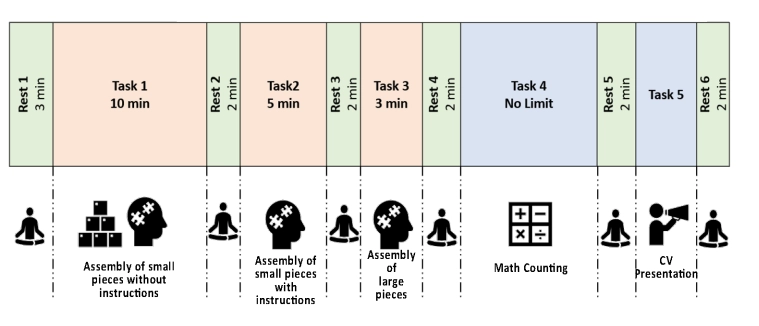

```
Rest → Task1 → Rest → Task2 → Rest → Task3 → Rest → Task4 → Rest → Task5 → Rest
```

- Task4는 전체 duration에서 나머지 구간 합을 빼서 구한다.


===== subject_01 protocol =====
Segment    Label      Start(s)     End(s)     Dur(s)
Rest1      normal         0.00     180.00     180.00
Task1      stress       180.00     780.00     600.00
Rest2      normal       780.00     900.00     120.00
Task2      stress       900.00    1200.00     300.00
Rest3      normal      1200.00    1320.00     120.00
Task3      stress      1320.00    1500.00     180.00
Rest4      normal      1500.00    1620.00     120.00
Task4      stress      1620.00    2205.77     585.77
Rest5      normal      2205.77    2325.77     120.00
Task5      stress      2325.77    2385.77      60.00
Rest6      normal      2385.77    2505.77     120.00


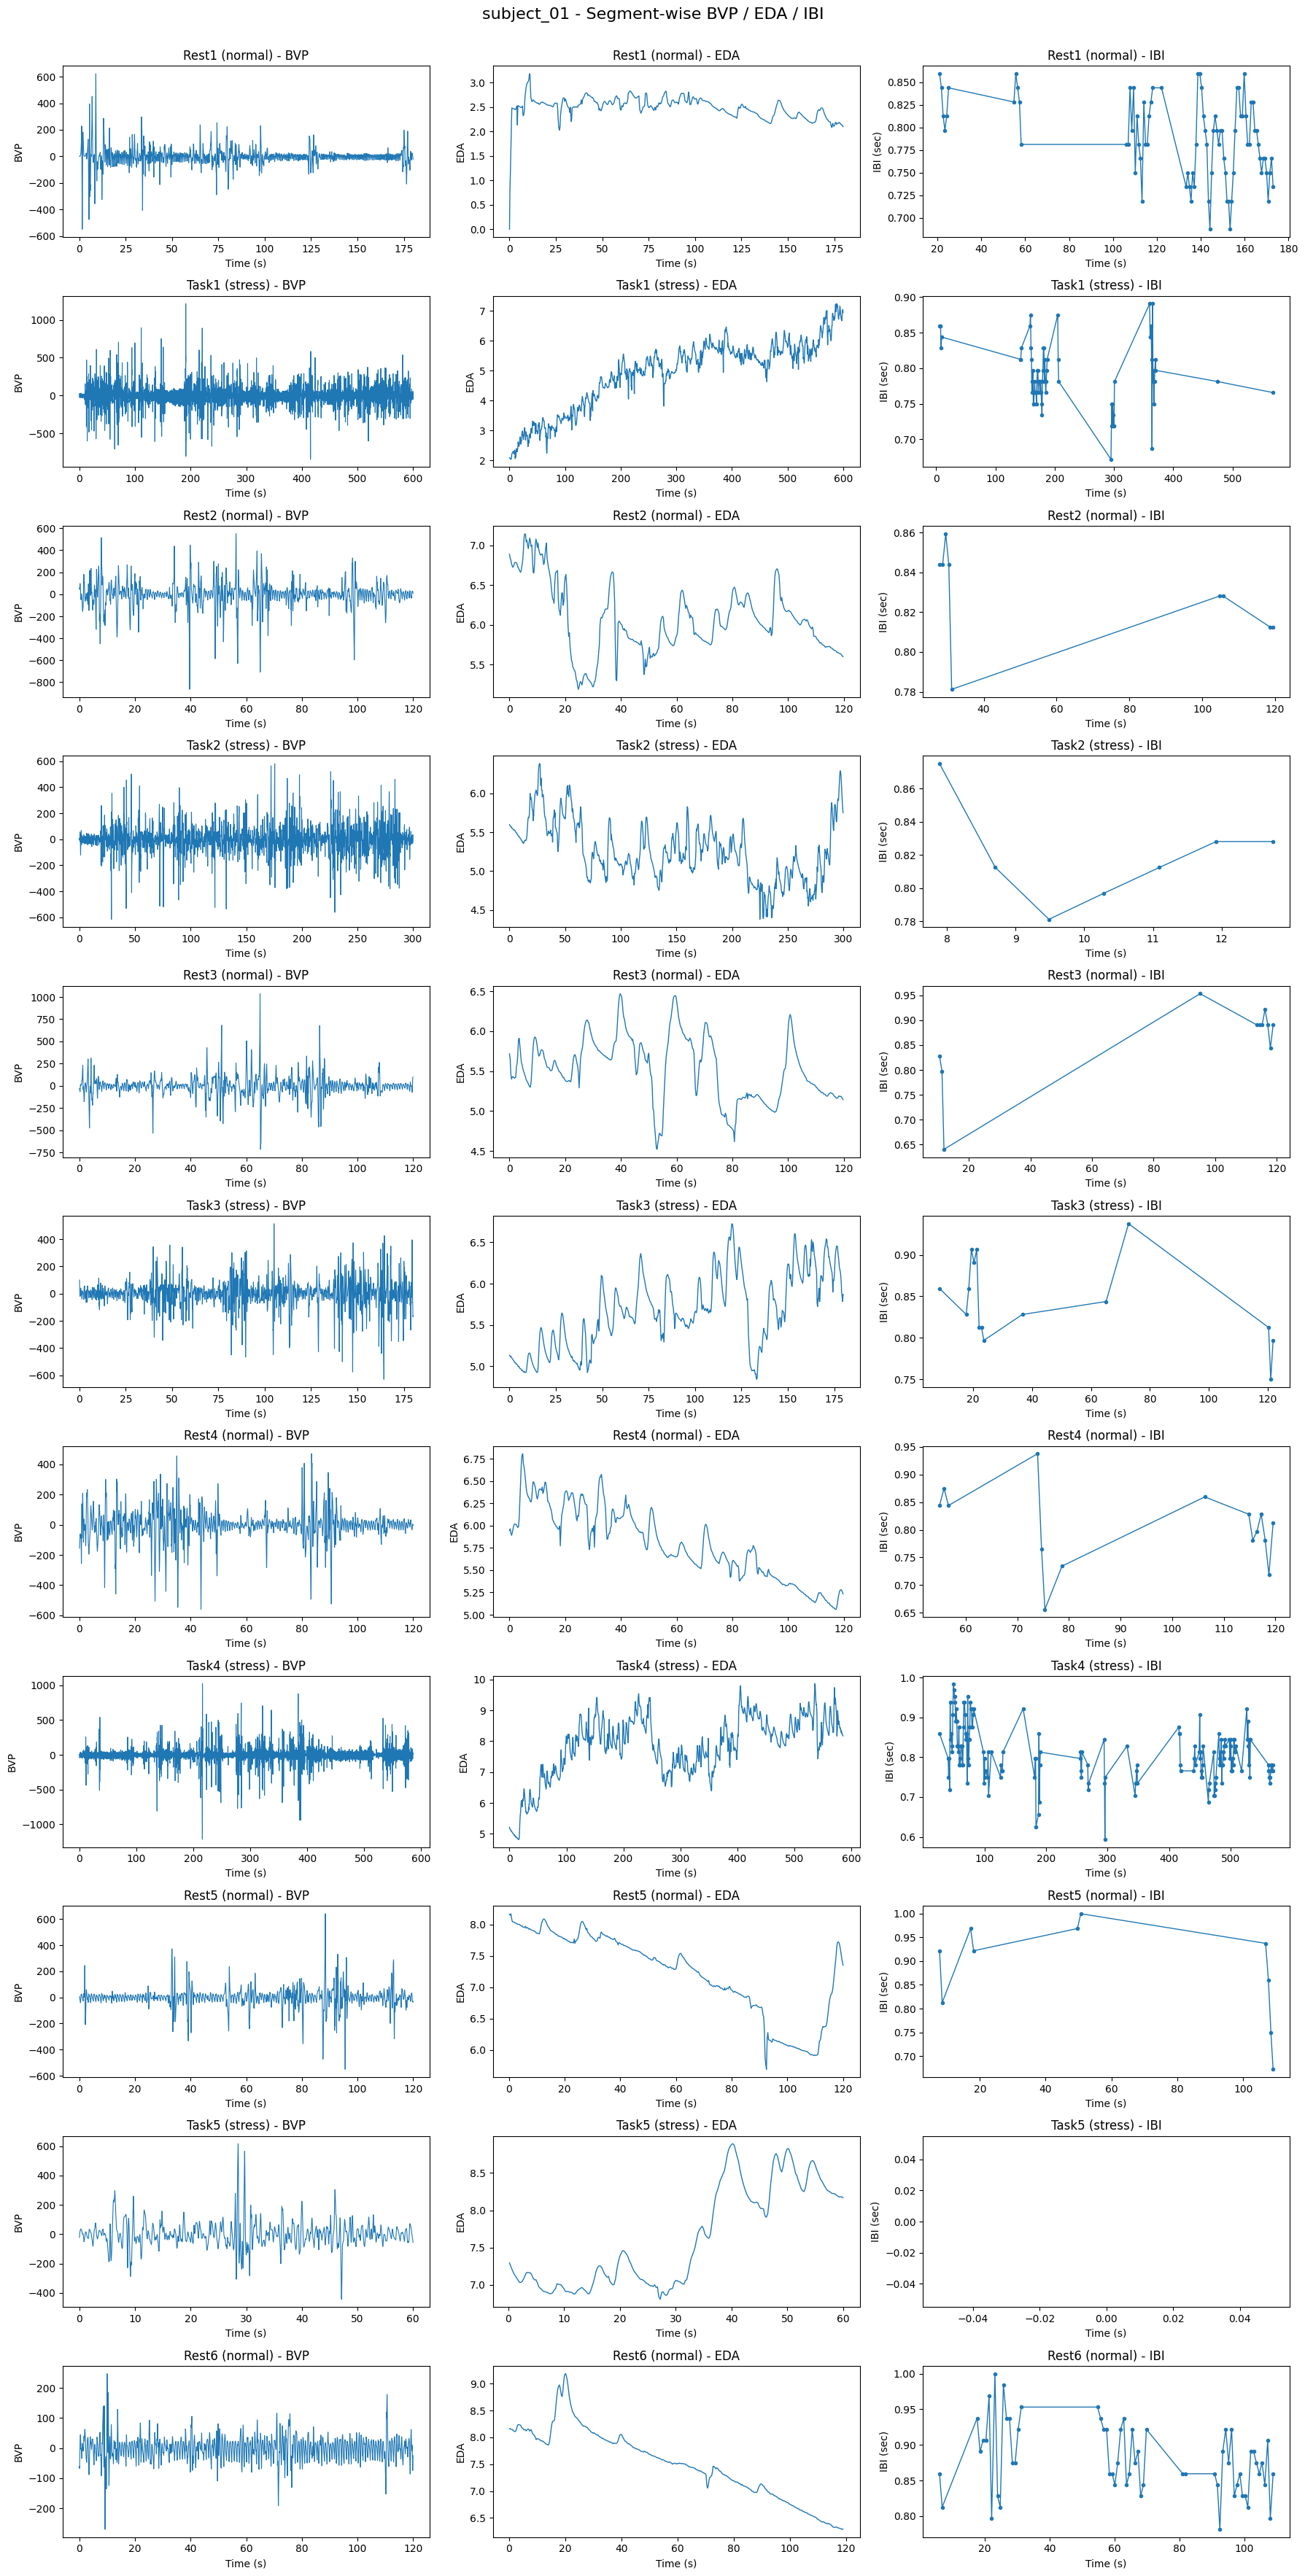

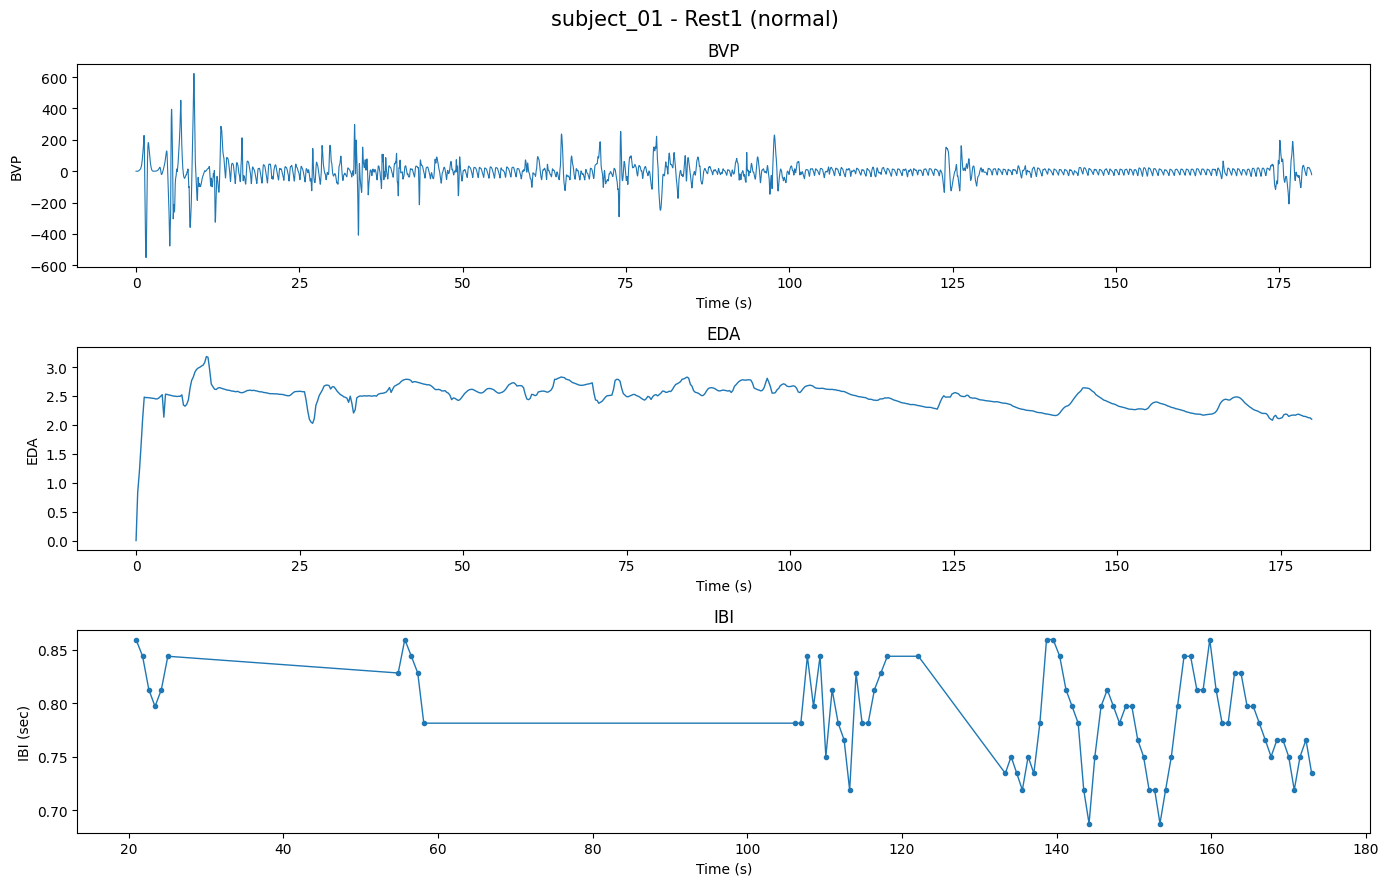

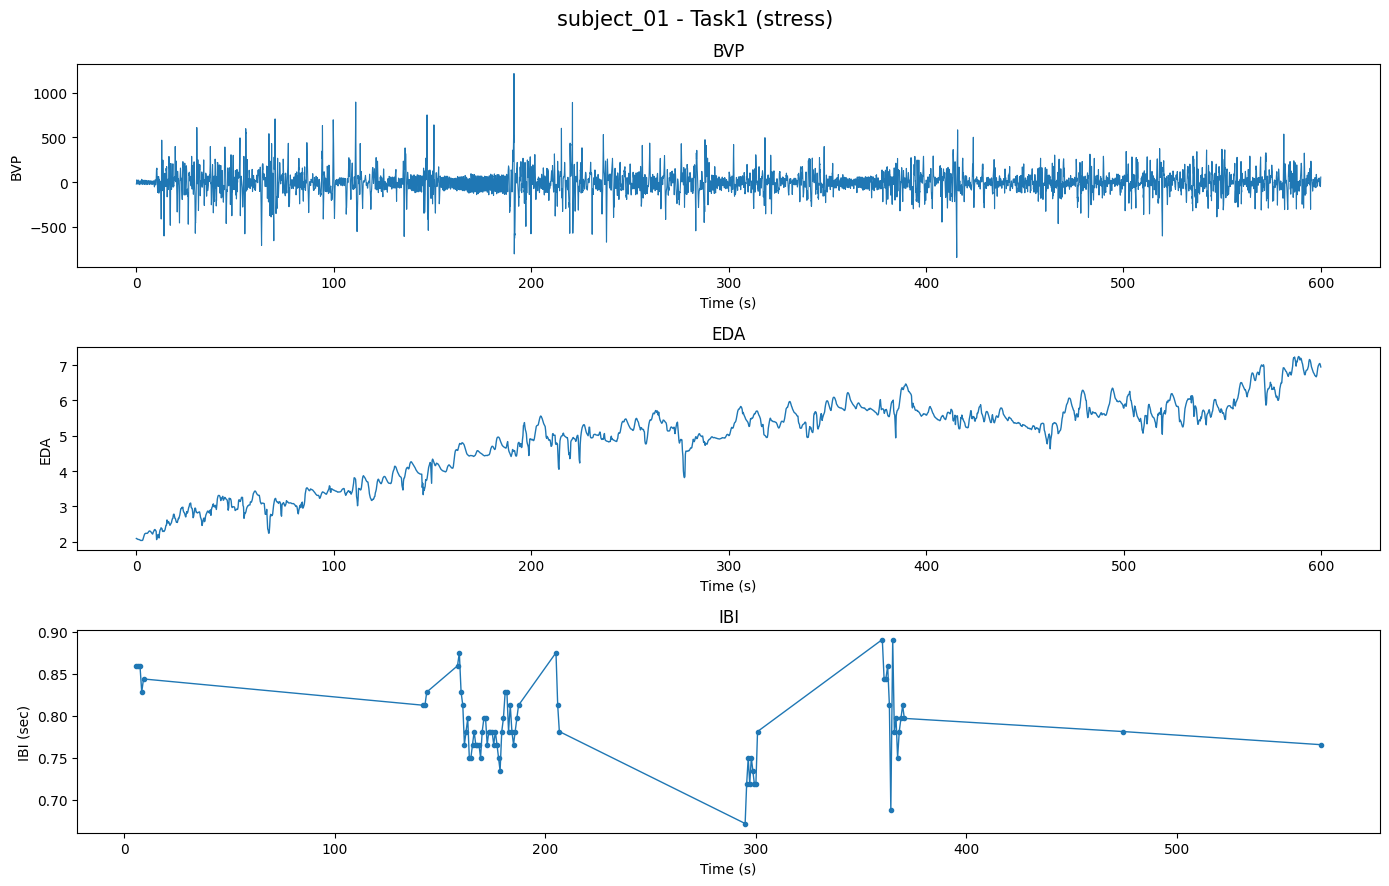

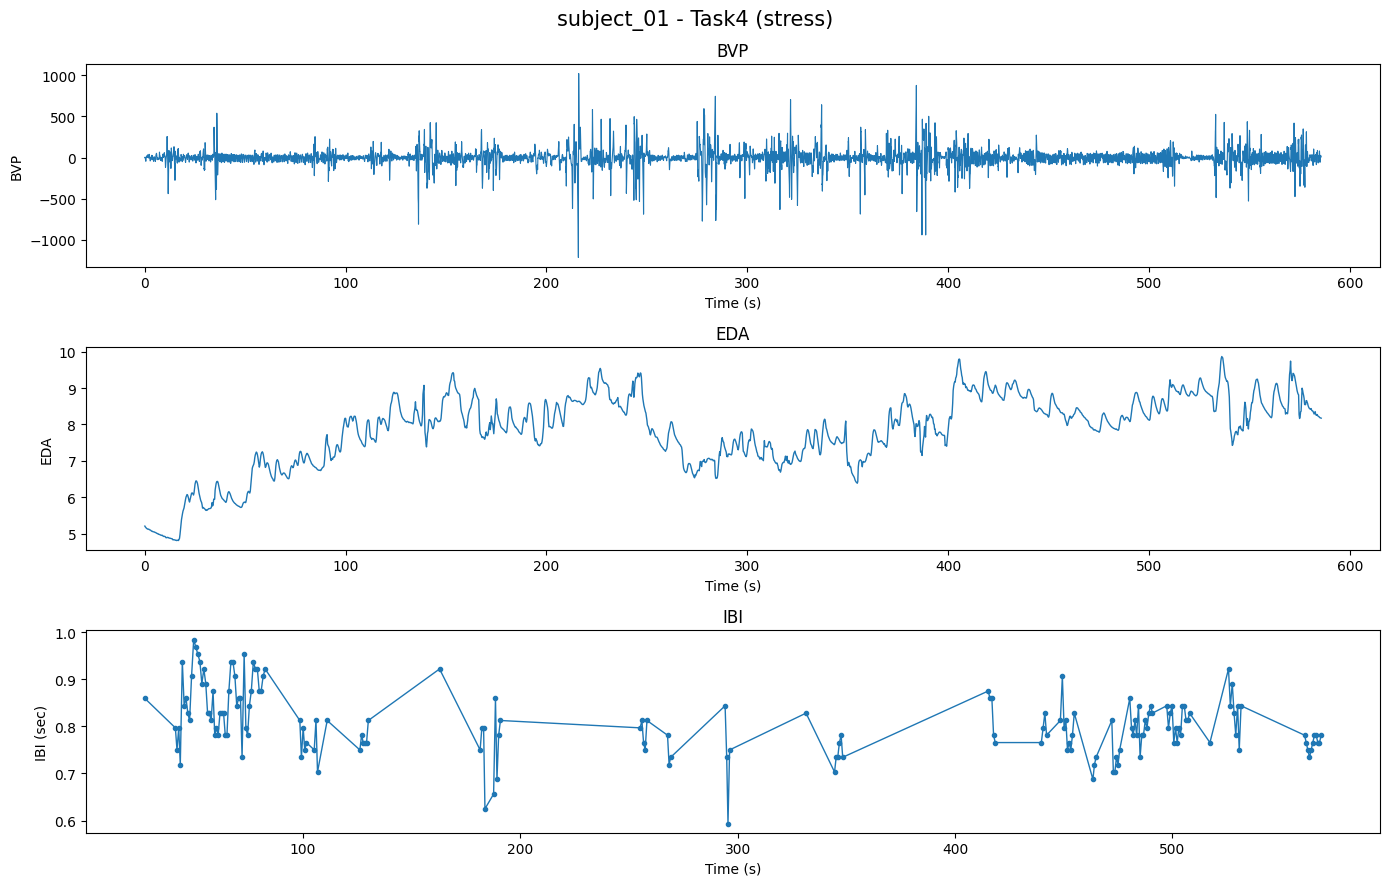

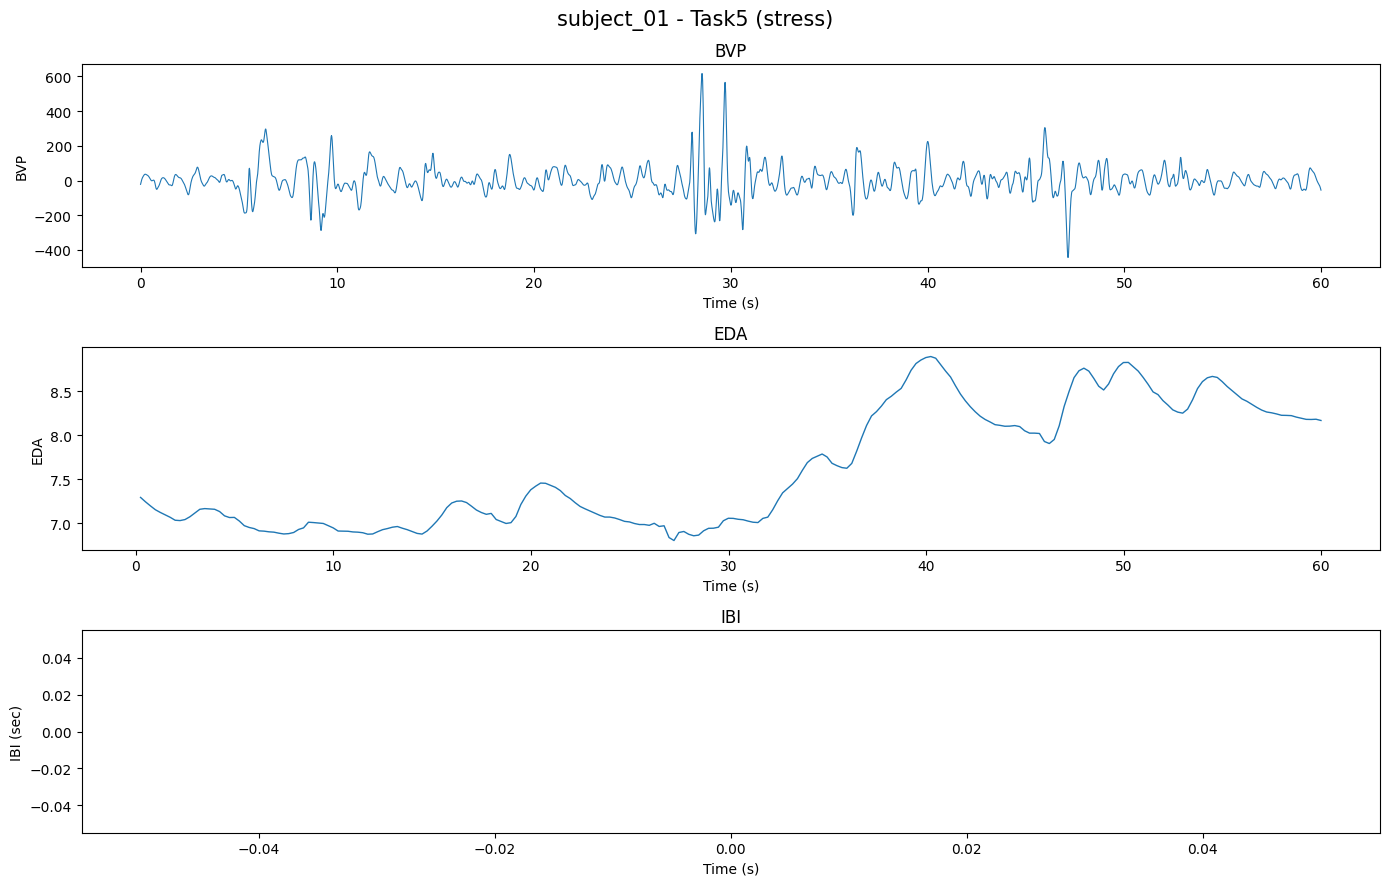

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. 프로토콜 정의
# =========================================================
# 고정 길이 구간들 (초)
# Task4만 가변
FIXED_PROTOCOL = [
    ("Rest1", 180, "normal"),
    ("Task1", 600, "stress"),
    ("Rest2", 120, "normal"),
    ("Task2", 300, "stress"),
    ("Rest3", 120, "normal"),
    ("Task3", 180, "stress"),
    ("Rest4", 120, "normal"),
    # ("Task4", variable, "stress"),
    ("Rest5", 120, "normal"),
    ("Task5", 60,  "stress"),
    ("Rest6", 120, "normal"),
]


# =========================================================
# 2. subject별 구간표 만들기
# =========================================================
def build_subject_protocol(subject_data, duration_source="BVP"):
    """
    duration_source:
        "BVP" or "EDA"
    BVP 전체 길이 기준으로 Task4 길이를 자동 추정
    """
    total_duration = subject_data[duration_source]["duration_sec"]

    fixed_sum_excluding_task4 = sum(d for name, d, lab in FIXED_PROTOCOL)
    task4_duration = total_duration - fixed_sum_excluding_task4

    if task4_duration <= 0:
        raise ValueError(
            f"Task4 duration <= 0. total={total_duration:.2f}, fixed_sum={fixed_sum_excluding_task4}"
        )

    protocol = [
        ("Rest1", 180, "normal"),
        ("Task1", 600, "stress"),
        ("Rest2", 120, "normal"),
        ("Task2", 300, "stress"),
        ("Rest3", 120, "normal"),
        ("Task3", 180, "stress"),
        ("Rest4", 120, "normal"),
        ("Task4", task4_duration, "stress"),
        ("Rest5", 120, "normal"),
        ("Task5", 60,  "stress"),
        ("Rest6", 120, "normal"),
    ]

    rows = []
    t = 0.0
    for seg_name, seg_dur, seg_label in protocol:
        rows.append({
            "segment": seg_name,
            "label": seg_label,
            "start_sec": t,
            "end_sec": t + seg_dur,
            "duration_sec": seg_dur
        })
        t += seg_dur

    return rows


# =========================================================
# 3. 구간별 signal slice
# =========================================================
def slice_signal_by_time(signal_dict, start_sec, end_sec):
    """
    signal_dict:
        BVP/EDA => timestamps, data
        IBI     => offsets, data
    """
    if "offsets" in signal_dict:
        t = signal_dict["offsets"]
    else:
        t = signal_dict["timestamps"]

    x = signal_dict["data"]

    mask = (t >= start_sec) & (t < end_sec)
    return t[mask], x[mask]


# =========================================================
# 4. 구간표 출력
# =========================================================
def print_protocol_table(protocol_rows):
    print("=" * 90)
    print(f"{'Segment':<10} {'Label':<8} {'Start(s)':>10} {'End(s)':>10} {'Dur(s)':>10}")
    print("=" * 90)
    for r in protocol_rows:
        print(f"{r['segment']:<10} {r['label']:<8} {r['start_sec']:>10.2f} {r['end_sec']:>10.2f} {r['duration_sec']:>10.2f}")
    print("=" * 90)


# =========================================================
# 5. 구간별 lineplot
# =========================================================
def plot_subject_segments(dataset, subject_name, normalize_time=True):
    """
    subject별 모든 구간에 대해
    BVP / EDA / IBI를 lineplot으로 시각화
    """
    subject_data = dataset[subject_name]
    protocol_rows = build_subject_protocol(subject_data, duration_source="BVP")

    print(f"\n===== {subject_name} protocol =====")
    print_protocol_table(protocol_rows)

    n_segments = len(protocol_rows)
    fig, axes = plt.subplots(n_segments, 3, figsize=(18, 3.2 * n_segments))
    fig.suptitle(f"{subject_name} - Segment-wise BVP / EDA / IBI", fontsize=16, y=1.002)

    if n_segments == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, row in enumerate(protocol_rows):
        seg_name = row["segment"]
        label = row["label"]
        start_sec = row["start_sec"]
        end_sec = row["end_sec"]

        # ---------------- BVP ----------------
        t_bvp, x_bvp = slice_signal_by_time(subject_data["BVP"], start_sec, end_sec)
        if normalize_time and len(t_bvp) > 0:
            t_bvp = t_bvp - start_sec

        axes[i, 0].plot(t_bvp, x_bvp, linewidth=0.8)
        axes[i, 0].set_title(f"{seg_name} ({label}) - BVP")
        axes[i, 0].set_xlabel("Time (s)")
        axes[i, 0].set_ylabel("BVP")

        # ---------------- EDA ----------------
        t_eda, x_eda = slice_signal_by_time(subject_data["EDA"], start_sec, end_sec)
        if normalize_time and len(t_eda) > 0:
            t_eda = t_eda - start_sec

        axes[i, 1].plot(t_eda, x_eda, linewidth=1.0)
        axes[i, 1].set_title(f"{seg_name} ({label}) - EDA")
        axes[i, 1].set_xlabel("Time (s)")
        axes[i, 1].set_ylabel("EDA")

        # ---------------- IBI ----------------
        t_ibi, x_ibi = slice_signal_by_time(subject_data["IBI"], start_sec, end_sec)
        if normalize_time and len(t_ibi) > 0:
            t_ibi = t_ibi - start_sec

        axes[i, 2].plot(t_ibi, x_ibi, marker="o", linewidth=1.0, markersize=3)
        axes[i, 2].set_title(f"{seg_name} ({label}) - IBI")
        axes[i, 2].set_xlabel("Time (s)")
        axes[i, 2].set_ylabel("IBI (sec)")

    plt.tight_layout()
    plt.show()


# =========================================================
# 6. 특정 구간만 확대해서 보기
# =========================================================
def plot_one_segment(dataset, subject_name, segment_name, normalize_time=True):
    subject_data = dataset[subject_name]
    protocol_rows = build_subject_protocol(subject_data, duration_source="BVP")

    target = None
    for row in protocol_rows:
        if row["segment"] == segment_name:
            target = row
            break

    if target is None:
        raise ValueError(f"{segment_name} not found")

    start_sec = target["start_sec"]
    end_sec = target["end_sec"]
    label = target["label"]

    fig, axes = plt.subplots(3, 1, figsize=(14, 9))
    fig.suptitle(f"{subject_name} - {segment_name} ({label})", fontsize=15)

    # BVP
    t_bvp, x_bvp = slice_signal_by_time(subject_data["BVP"], start_sec, end_sec)
    if normalize_time and len(t_bvp) > 0:
        t_bvp = t_bvp - start_sec
    axes[0].plot(t_bvp, x_bvp, linewidth=0.8)
    axes[0].set_title("BVP")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("BVP")

    # EDA
    t_eda, x_eda = slice_signal_by_time(subject_data["EDA"], start_sec, end_sec)
    if normalize_time and len(t_eda) > 0:
        t_eda = t_eda - start_sec
    axes[1].plot(t_eda, x_eda, linewidth=1.0)
    axes[1].set_title("EDA")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("EDA")

    # IBI
    t_ibi, x_ibi = slice_signal_by_time(subject_data["IBI"], start_sec, end_sec)
    if normalize_time and len(t_ibi) > 0:
        t_ibi = t_ibi - start_sec
    axes[2].plot(t_ibi, x_ibi, marker="o", linewidth=1.0, markersize=3)
    axes[2].set_title("IBI")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylabel("IBI (sec)")

    plt.tight_layout()
    plt.show()


# =========================================================
# 7. 실행 예시
# =========================================================
subject_name = "subject_01"

# 전체 구간별 시각화
plot_subject_segments(dataset, subject_name)

# 특정 구간만 확대
plot_one_segment(dataset, subject_name, "Rest1")
plot_one_segment(dataset, subject_name, "Task1")
plot_one_segment(dataset, subject_name, "Task4")
plot_one_segment(dataset, subject_name, "Task5")

In [9]:
subject_name = "subject_01"
segment_name = "Task5"

subject_data = dataset[subject_name]
protocol_rows = build_subject_protocol(subject_data, duration_source="BVP")

target = [r for r in protocol_rows if r["segment"] == segment_name][0]
start_sec = target["start_sec"]
end_sec = target["end_sec"]

t_ibi, x_ibi = slice_signal_by_time(subject_data["IBI"], start_sec, end_sec)

print("segment:", segment_name)
print("start_sec:", start_sec)
print("end_sec:", end_sec)
print("n_ibi_points:", len(t_ibi))
print("first few ibi times:", t_ibi[:10])
print("last few ibi times:", t_ibi[-10:])

segment: Task5
start_sec: 2325.765625
end_sec: 2385.765625
n_ibi_points: 0
first few ibi times: []
last few ibi times: []


1. subject별 전체 길이로 Task4 길이 역산
2. 각 신호(BVP / EDA / IBI)에 대해 timestamp별 label 부여
3. 60초 window, 60초 step
4. `major_ratio >= threshold` 인 window만 채택
5. subject별 normal/stress 개수 확인

In [10]:
import numpy as np
import pandas as pd

# =========================================================
# 1. subject별 protocol interval 만들기
# =========================================================
def build_protocol_intervals_from_duration(total_duration_sec):
    """
    total_duration_sec: 보통 BVP duration 기준
    return: interval list
    label: normal=0, stress=1
    """

    fixed_sum_excluding_task4 = (
        180 + 600 + 120 + 300 + 120 + 180 + 120 + 120 + 60 + 120
    )  # = 1920 sec

    task4_duration = total_duration_sec - fixed_sum_excluding_task4

    if task4_duration <= 0:
        raise ValueError(
            f"Task4 duration <= 0. total={total_duration_sec:.2f}, fixed_sum={fixed_sum_excluding_task4}"
        )

    segments = [
        ("Rest1", 180, 0),
        ("Task1", 600, 1),
        ("Rest2", 120, 0),
        ("Task2", 300, 1),
        ("Rest3", 120, 0),
        ("Task3", 180, 1),
        ("Rest4", 120, 0),
        ("Task4", task4_duration, 1),
        ("Rest5", 120, 0),
        ("Task5", 60, 1),
        ("Rest6", 120, 0),
    ]

    intervals = []
    t = 0.0
    for name, dur, label in segments:
        intervals.append({
            "segment": name,
            "start": t,
            "end": t + dur,
            "label": label
        })
        t += dur

    return intervals


# =========================================================
# 2. signal dict -> dataframe
# =========================================================
def signal_dict_to_df(signal_dict, signal_name):
    """
    dataset[subject]["BVP"/"EDA"/"IBI"] 를 dataframe으로 변환
    """
    if signal_name in ["BVP", "EDA"]:
        return pd.DataFrame({
            "timestamp": signal_dict["timestamps"],
            "value": signal_dict["data"]
        })

    elif signal_name == "IBI":
        return pd.DataFrame({
            "timestamp": signal_dict["offsets"],
            "value": signal_dict["data"]
        })

    else:
        raise ValueError(f"Unsupported signal_name: {signal_name}")


# =========================================================
# 3. interval label 부여
# =========================================================
def assign_intervals_to_signal_df(df, intervals):
    """
    각 timestamp가 어떤 interval에 속하는지 label 부여
    label: normal=0, stress=1
    """
    df = df.copy()
    df["label"] = np.nan
    df["segment"] = None

    for inter in intervals:
        mask = (df["timestamp"] >= inter["start"]) & (df["timestamp"] < inter["end"])
        df.loc[mask, "label"] = inter["label"]
        df.loc[mask, "segment"] = inter["segment"]

    # interval 밖 데이터 제거
    df = df.dropna(subset=["label"]).copy()
    df["label"] = df["label"].astype(int)
    return df


# =========================================================
# 4. window 생성
# =========================================================
def create_windows(df, window_size_sec=60, step_sec=60):
    windows = []

    start_time = df["timestamp"].min()
    end_time = df["timestamp"].max()

    t = start_time

    while t + window_size_sec <= end_time:
        window_df = df[(df["timestamp"] >= t) & (df["timestamp"] < t + window_size_sec)]

        if len(window_df) == 0:
            t += step_sec
            continue

        counts = window_df["label"].value_counts(normalize=True)

        major_label = counts.idxmax()
        major_ratio = counts.max()

        windows.append({
            "start": t,
            "end": t + window_size_sec,
            "label": int(major_label),
            "major_ratio": float(major_ratio),
            "n_points": len(window_df)
        })

        t += step_sec

    return pd.DataFrame(windows)


# =========================================================
# 5. subject별 window count 계산
# =========================================================
def compute_window_counts(dataset, signal="EDA", threshold=0.9,
                          duration_source="BVP",
                          window_size_sec=60, step_sec=60):
    results = []
    all_windows = {}

    for sid, subj in dataset.items():
        total_duration_sec = subj[duration_source]["duration_sec"]
        intervals = build_protocol_intervals_from_duration(total_duration_sec)

        df_signal = signal_dict_to_df(subj[signal], signal)
        df_labeled = assign_intervals_to_signal_df(df_signal, intervals)

        win_df = create_windows(
            df_labeled,
            window_size_sec=window_size_sec,
            step_sec=step_sec
        )

        if len(win_df) == 0:
            results.append({
                "subject": sid,
                "normal": 0,
                "stress": 0,
                "total": 0
            })
            all_windows[sid] = win_df
            continue

        # quality filter
        win_df = win_df[win_df["major_ratio"] >= threshold].copy()

        n0 = int((win_df["label"] == 0).sum())
        n1 = int((win_df["label"] == 1).sum())

        results.append({
            "subject": sid,
            "normal": n0,
            "stress": n1,
            "total": n0 + n1
        })

        all_windows[sid] = win_df

    return pd.DataFrame(results), all_windows


# =========================================================
# 6. interval sanity check
# =========================================================
def inspect_subject_intervals(dataset, subject_name, duration_source="BVP"):
    total_duration_sec = dataset[subject_name][duration_source]["duration_sec"]
    intervals = build_protocol_intervals_from_duration(total_duration_sec)

    rows = []
    for x in intervals:
        rows.append({
            "segment": x["segment"],
            "start": x["start"],
            "end": x["end"],
            "duration": x["end"] - x["start"],
            "label": x["label"]
        })

    df = pd.DataFrame(rows)
    print(f"\n===== {subject_name} intervals =====")
    print(df)
    print(f"\nTotal duration ({duration_source}): {total_duration_sec:.3f} sec")
    print(f"Task4 duration: {df.loc[df['segment']=='Task4', 'duration'].iloc[0]:.3f} sec")
    return df


# =========================================================
# 7. 실행 예시
# =========================================================
# 구간 sanity check
interval_df = inspect_subject_intervals(dataset, "subject_01", duration_source="BVP")

# EDA 기준 window count
df_counts_eda, all_windows_eda = compute_window_counts(
    dataset,
    signal="EDA",
    threshold=0.9,
    duration_source="BVP",
    window_size_sec=60,
    step_sec=60
)

print("\n[EDA window counts]")
print(df_counts_eda)

# BVP 기준 window count
df_counts_bvp, all_windows_bvp = compute_window_counts(
    dataset,
    signal="BVP",
    threshold=0.9,
    duration_source="BVP",
    window_size_sec=60,
    step_sec=60
)

print("\n[BVP window counts]")
print(df_counts_bvp)

# IBI 기준 window count
df_counts_ibi, all_windows_ibi = compute_window_counts(
    dataset,
    signal="IBI",
    threshold=0.9,
    duration_source="BVP",
    window_size_sec=60,
    step_sec=60
)

print("\n[IBI window counts]")
print(df_counts_ibi)

# 특정 subject window 확인
print("\n[subject_01 EDA windows]")
print(all_windows_eda["subject_01"].head())

print("\n[subject_01 IBI windows]")
print(all_windows_ibi["subject_01"].head())


===== subject_01 intervals =====
   segment        start          end    duration  label
0    Rest1     0.000000   180.000000  180.000000      0
1    Task1   180.000000   780.000000  600.000000      1
2    Rest2   780.000000   900.000000  120.000000      0
3    Task2   900.000000  1200.000000  300.000000      1
4    Rest3  1200.000000  1320.000000  120.000000      0
5    Task3  1320.000000  1500.000000  180.000000      1
6    Rest4  1500.000000  1620.000000  120.000000      0
7    Task4  1620.000000  2205.765625  585.765625      1
8    Rest5  2205.765625  2325.765625  120.000000      0
9    Task5  2325.765625  2385.765625   60.000000      1
10   Rest6  2385.765625  2505.765625  120.000000      0

Total duration (BVP): 2505.766 sec
Task4 duration: 585.766 sec

[EDA window counts]
       subject  normal  stress  total
0   subject_01      11      27     38
1   subject_02      11      25     36
2   subject_03       5      12     17
3   subject_04       9      18     27
4   subject_05     

1. IBI는 window 개수가 많지 않다. -> event-based signal로 sampling rate이 없고 각 데이터 포인트들은 심장 박동 간격을 나타낸다.
2. EDA는 subject마다 퀄리티 차이가 있는편이고 S23은 아예 결측이다.
3. BVP는 안정적이다.

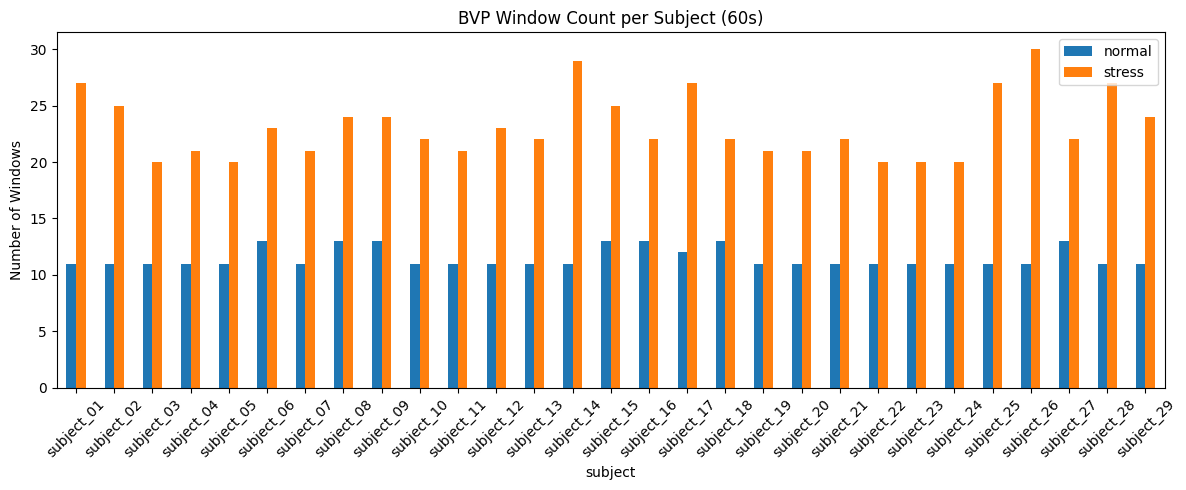

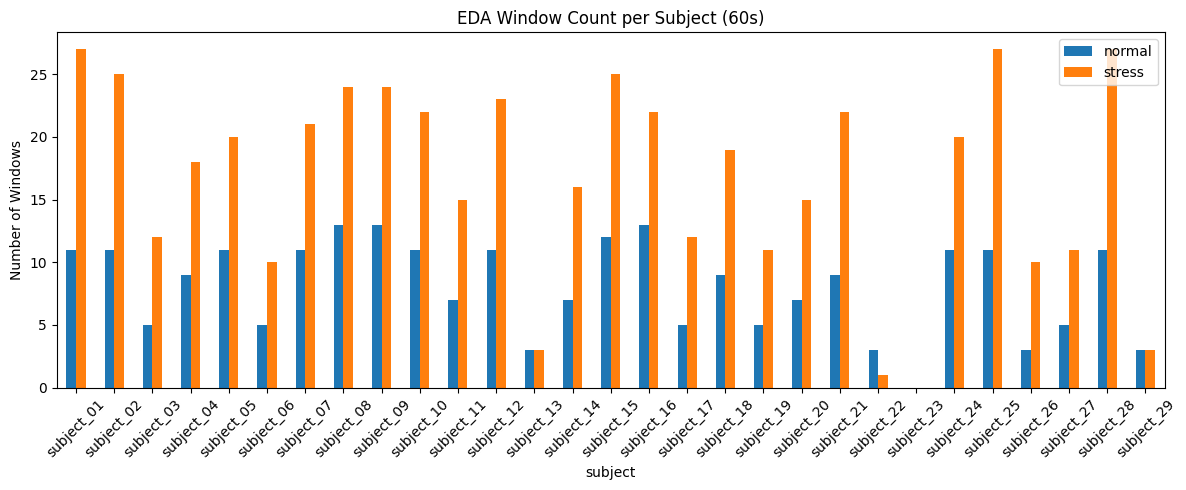

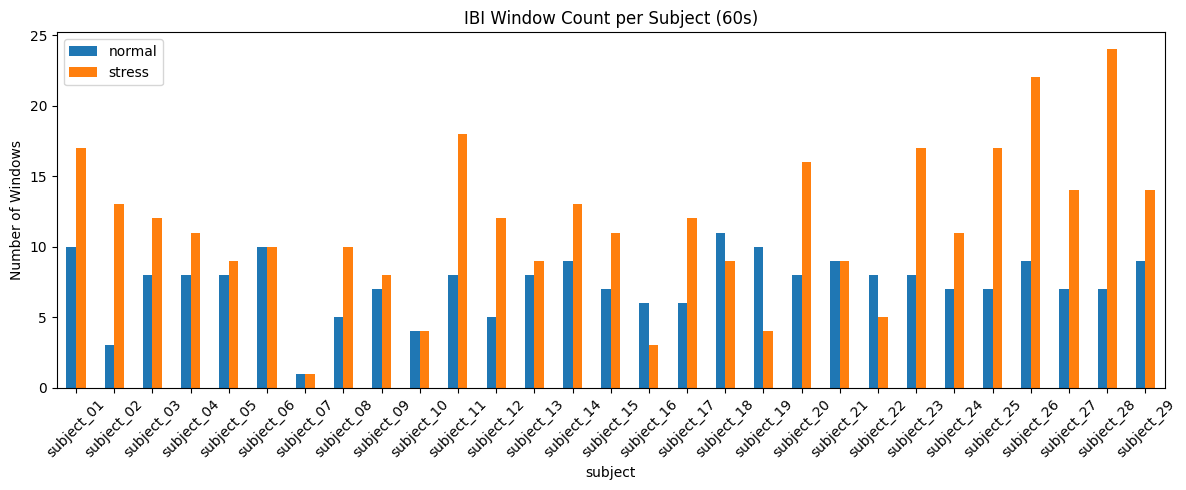

In [12]:
import matplotlib.pyplot as plt

def plot_window_counts(df_counts, title):
    df_counts = df_counts.set_index("subject")[["normal", "stress"]]

    df_counts.plot(
        kind="bar",
        figsize=(12,5)
    )

    plt.title(title)
    plt.ylabel("Number of Windows")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


# 각각 출력
plot_window_counts(df_counts_bvp, "BVP Window Count per Subject (60s)")
plot_window_counts(df_counts_eda, "EDA Window Count per Subject (60s)")
plot_window_counts(df_counts_ibi, "IBI Window Count per Subject (60s)")